# Sounds of Seattle Birds Classification Project

## Section 1: Load Packages and Inspect Files

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Check that the main files are readable
metadata = pd.read_csv("bird_metadata.csv")
train_df = pd.read_csv("train_extended.csv")

print("Metadata shape:", metadata.shape)
print("Train data shape:", train_df.shape)

display(metadata.head())
display(train_df.head())

Metadata shape: (1981, 31)
Train data shape: (23784, 29)


,Unnamed: 0,rating,playback_used,ebird_code,channels,date,duration,filename,species,title,...,xc_id,url,country,author,primary_label,longitude,time,recordist,license,fpath
0,166,5.0,no,amecro,2 (stereo),2020-07-12,44,XC575220.mp3,American Crow,XC575220 American Crow (Corvus brachyrhynchos),...,575220,https://www.xeno-canto.org/575220,United States,Michael Hurben,Corvus brachyrhynchos_American Crow,-93.37860,06:00,Michael Hurben,Creative Commons Attribution-NonCommercial-Sha...,dozenspecies/amecro/XC575220.mp3
1,169,5.0,no,amecro,2 (stereo),2020-06-17,41,XC569711.mp3,American Crow,XC569711 American Crow (Corvus brachyrhynchos ...,...,569711,https://www.xeno-canto.org/569711,United States,Russ Wigh,Corvus brachyrhynchos_American Crow,-81.05590,15:00,Russ Wigh,Creative Commons Attribution-NonCommercial-Sha...,dozenspecies/amecro/XC569711.mp3
2,171,5.0,no,amecro,1 (mono),2020-06-14,78,XC568365.mp3,American Crow,XC568365 American Crow (Corvus brachyrhynchos ...,...,568365,https://www.xeno-canto.org/568365,United States,Russ Wigh,Corvus brachyrhynchos_American Crow,-81.05590,07:00,Russ Wigh,Creative Commons Attribution-NonCommercial-Sha...,dozenspecies/amecro/XC568365.mp3
3,173,5.0,no,amecro,2 (stereo),0000-00-00,52,XC561291.mp3,American Crow,XC561291 American Crow (Corvus brachyrhynchos),...,561291,https://www.xeno-canto.org/561291,United States,Jim Berry,Corvus brachyrhynchos_American Crow,-79.23810,06:00,Jim Berry,Creative Commons Attribution-NonCommercial-Sha...,dozenspecies/amecro/XC561291.mp3
4,174,5.0,no,amecro,1 (mono),2019-04-18,13,XC556240.mp3,American Crow,XC556240 American Crow (Corvus brachyrhynchos),...,556240,https://www.xeno-canto.org/556240,United States,Caio Brito,Corvus brachyrhynchos_American Crow,-81.40509,18:35,Caio Brito,Creative Commons Attribution-NonCommercial-Sha...,dozenspecies/amecro/XC556240.mp3


,rating,playback_used,ebird_code,channels,date,duration,filename,species,title,secondary_labels,...,background,xc_id,url,country,author,primary_label,longitude,time,recordist,license
0,0.0,no,aldfly,2 (stereo),2019-06-11,49,XC554809.mp3,Alder Flycatcher,XC554809 Alder Flycatcher (Empidonax alnorum),[],...,NaN,554809,https://www.xeno-canto.org/554809,United States,Ron Overholtz,Empidonax alnorum_Alder Flycatcher,-149.9757,07:00,Ron Overholtz,Creative Commons Attribution-NonCommercial-Sha...
1,0.0,no,aldfly,2 (stereo),2020-04-14,21,XC552408.mp3,Alder Flycatcher,XC552408 Alder Flycatcher (Empidonax alnorum),[],...,NaN,552408,https://www.xeno-canto.org/552408,Colombia,Jerome Fischer,Empidonax alnorum_Alder Flycatcher,-74.6520,17:00,Jerome Fischer,Creative Commons Attribution-NonCommercial-Sha...
2,0.0,yes,aldfly,2 (stereo),2020-04-05,35,XC544552.mp3,Alder Flycatcher,XC544552 Alder Flycatcher (Empidonax alnorum),[],...,NaN,544552,https://www.xeno-canto.org/544552,Colombia,Jerome Fischer,Empidonax alnorum_Alder Flycatcher,-74.6520,07:00,Jerome Fischer,Creative Commons Attribution-NonCommercial-Sha...
3,0.0,yes,aldfly,2 (stereo),2020-04-05,12,XC544551.mp3,Alder Flycatcher,XC544551 Alder Flycatcher (Empidonax alnorum),[],...,NaN,544551,https://www.xeno-canto.org/544551,Colombia,Jerome Fischer,Empidonax alnorum_Alder Flycatcher,-74.6520,07:00,Jerome Fischer,Creative Commons Attribution-NonCommercial-Sha...
4,0.0,yes,aldfly,2 (stereo),2020-04-05,38,XC544550.mp3,Alder Flycatcher,XC544550 Alder Flycatcher (Empidonax alnorum),[],...,NaN,544550,https://www.xeno-canto.org/544550,Colombia,Jerome Fischer,Empidonax alnorum_Alder Flycatcher,-74.6520,07:00,Jerome Fischer,Creative Commons Attribution-NonCommercial-Sha...


Section 1 Summary: In this section, we loaded the main packages and checked that the metadata files could be read in JupyterLab. The metadata file has 1,981 rows and 31 columns, which matches the number of spectrogram samples. The extended training file is much larger because it contains the original/full metadata before filtering. This confirms that our files are in the correct folder and we can move on to reading the HDF5 spectrogram data.

## Section 2: Load and Inspect Spectrogram Data

In [3]:
# Open the spectrogram HDF5 file
f = h5py.File("bird_spectrograms.hdf5", "r")

# Check the species stored in the file
species_list = list(f.keys())

print("Species in HDF5 file:")
print(species_list)

print("\nNumber of species:", len(species_list))

Species in HDF5 file:
['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 'sonspa', 'spotow', 'whcspa']

Number of species: 12


In [4]:
# Check the shape of each species dataset
total_samples = 0

for species in species_list:
    shape = f[species].shape
    total_samples += shape[2]
    print(species, shape)

print("\nTotal spectrogram samples:", total_samples)

amecro (128, 517, 66)
amerob (128, 517, 172)
bewwre (128, 517, 144)
bkcchi (128, 517, 45)
daejun (128, 517, 125)
houfin (128, 517, 84)
houspa (128, 517, 630)
norfli (128, 517, 37)
rewbla (128, 517, 187)
sonspa (128, 517, 263)
spotow (128, 517, 137)
whcspa (128, 517, 91)

Total spectrogram samples: 1981


Section 2 Summary: In this section, we loaded the HDF5 spectrogram file and confirmed that it contains 12 bird species. Each species dataset has spectrogram images shaped as 128 frequency bins by 517 time steps, with the number of samples varying by species. The total number of spectrogram samples is 1,981, which matches the metadata file. We also confirmed that the dataset is imbalanced, since some species have many more samples than others.

## Section 3: Visualize Class Distribution

In [5]:
# Create a table of sample counts by species
class_counts = []

for species in species_list:
    class_counts.append({
        "species": species,
        "samples": f[species].shape[2]
    })

class_counts_df = pd.DataFrame(class_counts)

display(class_counts_df)

,species,samples
0,amecro,66
1,amerob,172
2,bewwre,144
3,bkcchi,45
4,daejun,125
5,houfin,84
6,houspa,630
7,norfli,37
8,rewbla,187
9,sonspa,263


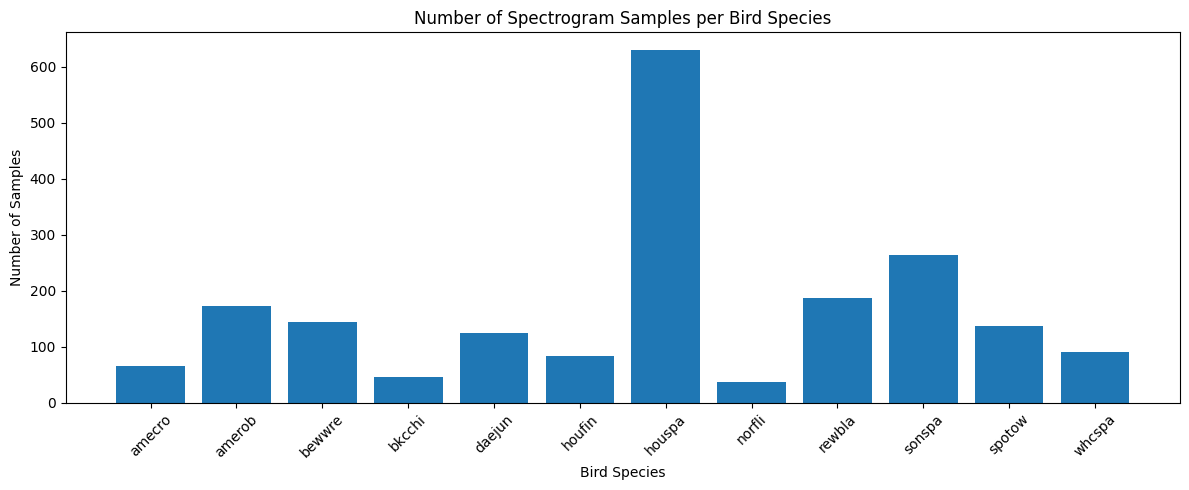

In [6]:
plt.figure(figsize=(12, 5))
plt.bar(class_counts_df["species"], class_counts_df["samples"])
plt.title("Number of Spectrogram Samples per Bird Species")
plt.xlabel("Bird Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Section 3 Summary: In this section, we examined the number of spectrogram samples available for each bird species. The dataset is clearly imbalanced, with some species such as houspa having significantly more training examples than others like norfli. This imbalance may influence model performance because neural networks tend to learn more effectively from classes with larger amounts of training data. The visualization also helps identify which species may be more difficult to classify later in the project.

## Section 4: Build Dataset Arrays

In [7]:
X = []
y = []

for species in species_list:
    
    # Load spectrogram data for this species
    data = f[species][:]
    
    # Current shape:
    # (128, 517, number_of_samples)
    
    # Move samples to first dimension
    data = np.transpose(data, (2, 0, 1))
    
    # Add each sample to X
    for sample in data:
        X.append(sample)
        y.append(species)

# Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1981, 128, 517)
y shape: (1981,)


Section 4 Summary: In this section, we combined all spectrogram datasets into a single feature array (X) and created a matching label array (y) containing the bird species names. The spectrogram samples were reorganized so that each individual sample became its own observation in the dataset. The final dataset contains 1,981 spectrogram images, each with dimensions 128 × 517, along with corresponding class labels for the 12 bird species.

## Section 5: Encode Labels and Normalize Data

In [8]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [9]:
# Convert bird species names into numbers
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("First 10 encoded labels:")
print(y_encoded[:10])

print("\nSpecies mapping:")
for i, species in enumerate(label_encoder.classes_):
    print(i, "=", species)

First 10 encoded labels:
[0 0 0 0 0 0 0 0 0 0]

Species mapping:
0 = amecro
1 = amerob
2 = bewwre
3 = bkcchi
4 = daejun
5 = houfin
6 = houspa
7 = norfli
8 = rewbla
9 = sonspa
10 = spotow
11 = whcspa


In [10]:
# Normalize spectrogram values to range 0-1
X = X.astype("float32")

X_min = X.min()
X_max = X.max()

X = (X - X_min) / (X_max - X_min)

print("Minimum value:", X.min())
print("Maximum value:", X.max())

Minimum value: 0.0
Maximum value: 1.0


In [11]:
# Add channel dimension for CNN
X = X[..., np.newaxis]

print("New X shape:", X.shape)

New X shape: (1981, 128, 517, 1)


Section 5 Summary: In this section, we converted the bird species labels from text into numeric class labels using LabelEncoder, which allows the neural network to process the targets correctly. We also normalized the spectrogram intensity values to a range between 0 and 1 to improve training stability and model performance. Finally, we reshaped the dataset to include a channel dimension so the spectrograms could be treated as grayscale images for convolutional neural network input.

## Section 6: Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training set shape: (1584, 128, 517, 1)
Testing set shape: (397, 128, 517, 1)
Training labels shape: (1584,)
Testing labels shape: (397,)


Section 6 Summary: In this section, we divided the dataset into training and testing sets using an 80/20 split. The training set contains 1,584 samples, while the testing set contains 397 samples. We also used stratified sampling to preserve the class distribution across both sets, which is important because the dataset is imbalanced. This allows the model to be evaluated more fairly on unseen data.

## Section 7: Baseline CNN Model

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [15]:
model = Sequential()

# First convolution block
model.add(Conv2D(
    16,
    (3, 3),
    activation='relu',
    input_shape=(128, 517, 1)
))

model.add(MaxPooling2D((2, 2)))

# Second convolution block
model.add(Conv2D(
    32,
    (3, 3),
    activation='relu'
))

model.add(MaxPooling2D((2, 2)))

# Flatten for dense layers
model.add(Flatten())

# Dense layer
model.add(Dense(64, activation='relu'))

# Dropout to reduce overfitting
model.add(Dropout(0.3))

# Output layer
model.add(Dense(12, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# View architecture
model.summary()

/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 515, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 257, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 255, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 121920)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     7,802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,808,524 (29.79 MB)

 Trainable params: 7,808,524 (29.79 MB)

 Non-trainable params: 0 (0.00 B)

Section 7 Summary: In this section, we built the first baseline convolutional neural network for multi-class bird classification. The model uses two convolutional layers with max pooling to learn spatial and frequency patterns from the spectrogram images, followed by dense layers for classification. Dropout regularization was included to help reduce overfitting. The baseline model contains approximately 7.8 million trainable parameters, with most parameters coming from the fully connected dense layer after flattening the feature maps.

## Section 8: Train the Baseline CNN

In [16]:
import time

start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

end_time = time.time()

training_time = end_time - start_time
print("Training time in seconds:", training_time)
print("Training time in minutes:", training_time / 60)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.2431 - loss: 2.6891 - val_accuracy: 0.3438 - val_loss: 2.3036
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.2920 - loss: 2.3131 - val_accuracy: 0.3438 - val_loss: 2.2301
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.2881 - loss: 2.2853 - val_accuracy: 0.3344 - val_loss: 2.2303
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.2960 - loss: 2.2252 - val_accuracy: 0.3407 - val_loss: 2.1437
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.3125 - loss: 2.1893 - val_accuracy: 0.3438 - val_loss: 2.1539
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.3078 - loss: 2.1354 - val_accuracy: 0.3438 - val_loss: 2.1170
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.3141 - loss: 2.0953 - val_accuracy: 0.3502 - val_loss: 2.0924
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - accuracy: 0.3252 - loss: 2.0860 - val_accuracy: 0.

Section 8 Summary: In this section, we trained the baseline convolutional neural network for 10 epochs using the training dataset. The model reached approximately 34.0% training accuracy and 36.0% validation accuracy, showing that it learned some spectrogram patterns from the bird calls but still struggled to distinguish between all 12 species. The relatively similar training and validation accuracies suggest that the model was not heavily overfitting, though overall performance remained limited. The full training process completed in under one minute.

## Section 9: Evaluate Model Performance

In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3300 - loss: 2.0173
Test Loss: 2.0172688961029053
Test Accuracy: 0.32997480034828186


Section 9 Summary: In this section, we evaluated the trained CNN on the unseen test dataset. The model achieved approximately 33.0% test accuracy on the unseen test dataset. While the model learned some spectrogram patterns, the relatively low accuracy suggests that distinguishing between all 12 bird species is challenging and that there is room for architectural improvements and additional tuning.

## Section 10: Plot Training History

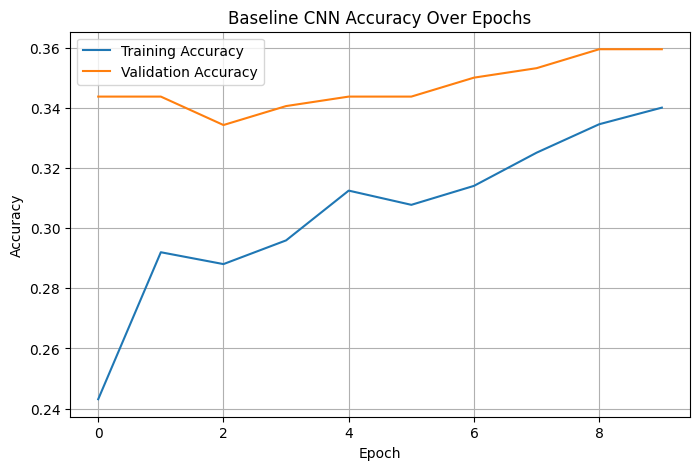

In [18]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline CNN Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

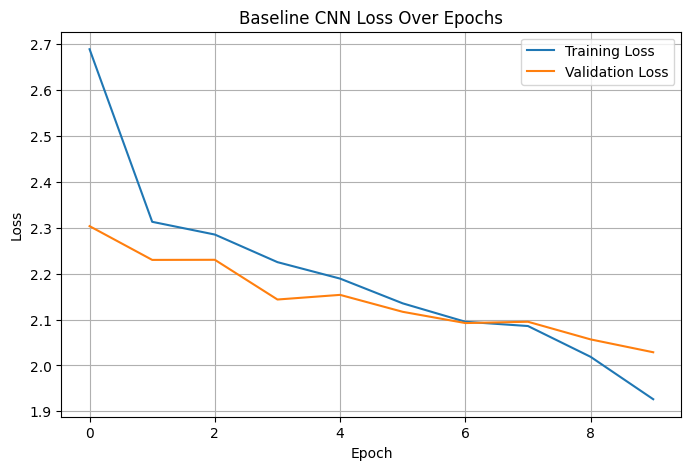

In [19]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Baseline CNN Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Section 10 Summary: In this section, we visualized the training and validation accuracy and loss across epochs for the baseline CNN. The training accuracy steadily improved while the validation accuracy increased more slowly and eventually began to level off. Similarly, the training loss continued decreasing while the validation loss fluctuated during later epochs. These patterns suggest that the model was beginning to overfit the training data after several epochs, indicating that additional regularization or architectural adjustments may improve generalization performance.

## Section 11: Confusion Matrix and Classification Report

In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [21]:
# Generate predictions
y_pred_probs = model.predict(X_test)

# Convert probabilities into predicted classes
y_pred = np.argmax(y_pred_probs, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


<Figure size 1200x1000 with 0 Axes>

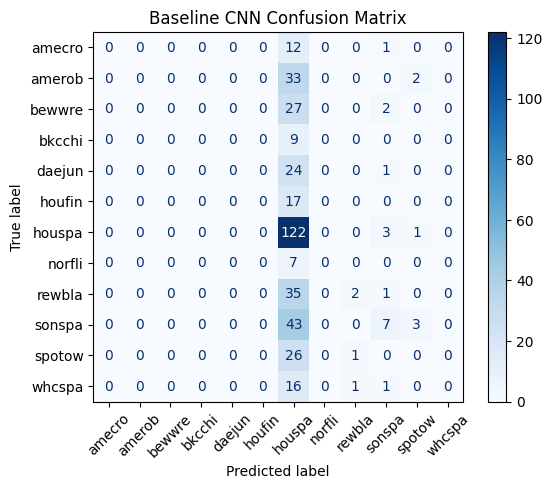

In [22]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Baseline CNN Confusion Matrix")
plt.show()

In [70]:
# Print classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

      amecro       0.00      0.00      0.00        13
      amerob       0.00      0.00      0.00        35
      bewwre       0.00      0.00      0.00        29
      bkcchi       0.00      0.00      0.00         9
      daejun       0.00      0.00      0.00        25
      houfin       0.00      0.00      0.00        17
      houspa       0.33      0.97      0.49       126
      norfli       0.00      0.00      0.00         7
      rewbla       0.50      0.05      0.10        38
      sonspa       0.44      0.13      0.20        53
      spotow       0.00      0.00      0.00        27
      whcspa       0.00      0.00      0.00        18

    accuracy                           0.33       397
   macro avg       0.11      0.10      0.07       397
weighted avg       0.21      0.33      0.19       397



/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [71]:
baseline_report_dict = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

baseline_macro_precision = baseline_report_dict["macro avg"]["precision"]
baseline_macro_recall = baseline_report_dict["macro avg"]["recall"]
baseline_macro_f1 = baseline_report_dict["macro avg"]["f1-score"]

baseline_weighted_precision = baseline_report_dict["weighted avg"]["precision"]
baseline_weighted_recall = baseline_report_dict["weighted avg"]["recall"]
baseline_weighted_f1 = baseline_report_dict["weighted avg"]["f1-score"]

Section 11 Summary: In this section, we evaluated the baseline CNN using a confusion matrix and classification report. The model achieved an overall test accuracy of approximately 33%. Performance was strongest on bird species with larger numbers of training samples, particularly houspa, while many smaller classes had very low precision and recall. This suggests that class imbalance made it difficult for the model to generalize evenly across all species.

## Section 12: Predict External Test Bird Clips

In [24]:
import sys

!{sys.executable} -m pip install librosa

In [25]:
import librosa
import librosa.display

In [65]:
def process_test_clip(file_path):
    """
    Load an mp3 test clip and convert it into the same spectrogram format
    used for the training data.
    """
    
    # Load first 3 seconds of audio
    y_audio, sr = librosa.load(file_path, duration=3)
    
    # Create mel spectrogram using same settings from professor notebook
    spec = librosa.feature.melspectrogram(
        y=y_audio,
        sr=sr,
        hop_length=128,
        win_length=512
    )
    
    # Convert power spectrogram to decibels
    spec_db = librosa.power_to_db(spec, ref=np.max)
    
    # Normalize using the SAME min/max from training data
    spec_db = (spec_db - X_min) / (X_max - X_min)
    
    # Add sample dimension and channel dimension
    spec_db = spec_db[np.newaxis, ..., np.newaxis]
    
    return spec_db

In [66]:
test_files = [
    "test_birds/test1.mp3",
    "test_birds/test2.mp3",
    "test_birds/test3.mp3"
]

test_predictions = []

for file_path in test_files:
    
    processed_clip = process_test_clip(file_path)
    
    prediction_probs = model.predict(processed_clip)
    predicted_class = np.argmax(prediction_probs)
    predicted_species = label_encoder.inverse_transform([predicted_class])[0]
    confidence = np.max(prediction_probs)
    
    test_predictions.append({
        "file": file_path,
        "predicted_species": predicted_species,
        "confidence": confidence
    })

test_predictions_df = pd.DataFrame(test_predictions)
display(test_predictions_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,file,predicted_species,confidence
0,test_birds/test1.mp3,houspa,0.375232
1,test_birds/test2.mp3,houspa,0.642057
2,test_birds/test3.mp3,houspa,0.283404


Section 12 Summary: In this section, we used the trained CNN model to classify three external unlabeled bird audio clips. Each mp3 file was converted into a mel spectrogram using the same preprocessing settings used during training. The model predicted all three clips as houspa, with confidence scores ranging from approximately 28% to 64%. The relatively low confidence values suggest that the model was uncertain in some of its predictions, which may reflect the difficulty of distinguishing bird species from limited audio samples and the class imbalance present in the training dataset.

## Section 13: Improved CNN Model

In [28]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
improved_model = Sequential()

# First convolution block
improved_model.add(Conv2D(16, (3, 3), activation='relu', input_shape=(128, 517, 1)))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D((2, 2)))

# Second convolution block
improved_model.add(Conv2D(32, (3, 3), activation='relu'))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D((2, 2)))

# Third convolution block
improved_model.add(Conv2D(64, (3, 3), activation='relu'))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D((2, 2)))

# Flatten and classify
improved_model.add(Flatten())
improved_model.add(Dense(128, activation='relu'))
improved_model.add(Dropout(0.5))
improved_model.add(Dense(12, activation='softmax'))

improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 515, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 515, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 257, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 255, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 255, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 125, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 55552)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,136,076 (27.22 MB)

 Trainable params: 7,135,852 (27.22 MB)

 Non-trainable params: 224 (896.00 B)

Section 13 Summary: In this section, we created an improved CNN architecture by adding an additional convolutional block and BatchNormalization layers. The updated model increases feature extraction capacity by using progressively larger filter sizes (16, 32, and 64 filters) while also adding Dropout regularization to reduce overfitting. Compared to the baseline CNN, this model is deeper and better structured for learning more complex spectrogram patterns from bird audio data.

#### Train the Improved Model

In [30]:
# Early stopping to reduce overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train improved model
improved_history = improved_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 320ms/step - accuracy: 0.2342 - loss: 7.7396 - val_accuracy: 0.0630 - val_loss: 65.4337
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 314ms/step - accuracy: 0.3176 - loss: 2.5153 - val_accuracy: 0.0630 - val_loss: 104.6825
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 313ms/step - accuracy: 0.3182 - loss: 2.4447 - val_accuracy: 0.0630 - val_loss: 116.6361
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 315ms/step - accuracy: 0.3194 - loss: 2.4141 - val_accuracy: 0.0630 - val_loss: 114.8293


Section 13 summary two: In this experiment, we trained a deeper CNN with three convolutional blocks and BatchNormalization. However, the model performed worse than the baseline CNN, with validation accuracy dropping and validation loss becoming very large. This suggests that the deeper model was unstable for this dataset and did not generalize well. The result shows that increasing model complexity does not always improve performance, especially with imbalanced data and limited samples.

## Section 14: Stable Improved CNN

In [31]:
stable_model = Sequential()

# First convolution block
stable_model.add(Conv2D(16, (3, 3), activation='relu', input_shape=(128, 517, 1)))
stable_model.add(MaxPooling2D((2, 2)))

# Second convolution block
stable_model.add(Conv2D(32, (3, 3), activation='relu'))
stable_model.add(MaxPooling2D((2, 2)))

# Third convolution block
stable_model.add(Conv2D(64, (3, 3), activation='relu'))
stable_model.add(MaxPooling2D((2, 2)))

# Dense layers
stable_model.add(Flatten())

stable_model.add(Dense(128, activation='relu'))
stable_model.add(Dropout(0.4))

stable_model.add(Dense(12, activation='softmax'))

stable_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

stable_model.summary()

/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 126, 515, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 257, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 255, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 55552)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,135,628 (27.22 MB)

 Trainable params: 7,135,628 (27.22 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
stable_history = stable_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.3018 - loss: 2.2807 - val_accuracy: 0.3174 - val_loss: 2.1755
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.3176 - loss: 2.1745 - val_accuracy: 0.3174 - val_loss: 2.1067
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.3258 - loss: 2.1035 - val_accuracy: 0.3224 - val_loss: 2.0169
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.3567 - loss: 1.9826 - val_accuracy: 0.3980 - val_loss: 1.9095
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.4135 - loss: 1.8444 - val_accuracy: 0.4030 - val_loss: 1.8457
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.4520 - loss: 1.6792 - val_accuracy: 0.4282 - val_loss: 1.8600
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.5240 - loss: 1.4772 - val_accuracy: 0.4257 - val_loss: 1.8165
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.5840 - loss: 1.2774 - val_accuracy: 

In [33]:
stable_test_loss, stable_test_accuracy = stable_model.evaluate(X_test, y_test)

print("Stable Model Test Loss:", stable_test_loss)
print("Stable Model Test Accuracy:", stable_test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4257 - loss: 1.8165
Stable Model Test Loss: 1.8165369033813477
Stable Model Test Accuracy: 0.42569270730018616


## Stable CNN Accuracy Plot

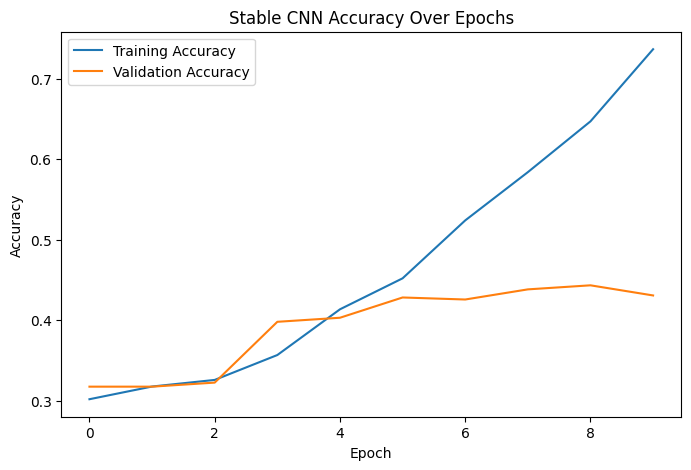

In [72]:
plt.figure(figsize=(8,5))
plt.plot(stable_history.history['accuracy'], label='Training Accuracy')
plt.plot(stable_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Stable CNN Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Stable CNN Loss Plot

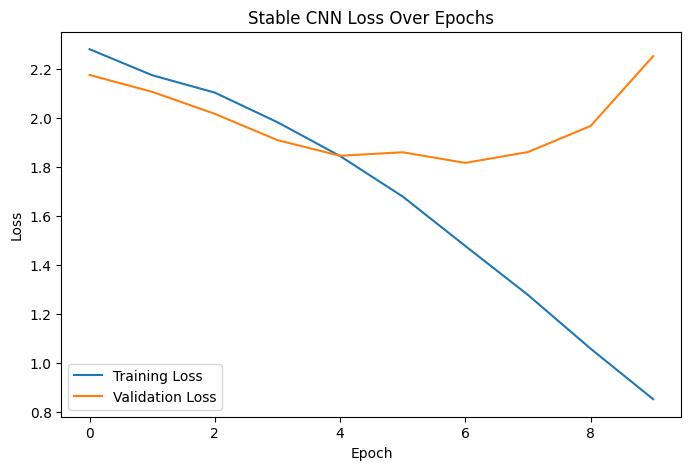

In [73]:
plt.figure(figsize=(8,5))
plt.plot(stable_history.history['loss'], label='Training Loss')
plt.plot(stable_history.history['val_loss'], label='Validation Loss')

plt.title('Stable CNN Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Section Summary: The Stable Improved CNN demonstrated stronger learning performance than the Baseline CNN. Training accuracy increased steadily while training loss decreased throughout the learning process. Validation accuracy peaked at approximately 44%, and validation loss reached its minimum near epoch 6 before increasing slightly, indicating mild overfitting. Overall, the training history suggests that the model successfully learned meaningful spectrogram patterns and achieved improved generalization performance.

## Stable Improved CNN Confusion Matrix and Classification Report

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


<Figure size 1200x1000 with 0 Axes>

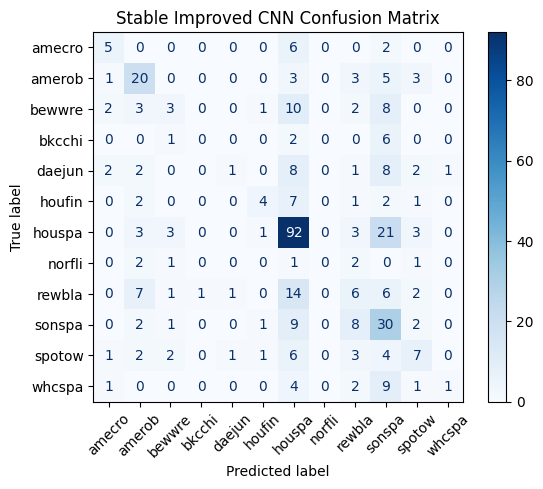

              precision    recall  f1-score   support

      amecro       0.42      0.38      0.40        13
      amerob       0.47      0.57      0.51        35
      bewwre       0.25      0.10      0.15        29
      bkcchi       0.00      0.00      0.00         9
      daejun       0.33      0.04      0.07        25
      houfin       0.50      0.24      0.32        17
      houspa       0.57      0.73      0.64       126
      norfli       0.00      0.00      0.00         7
      rewbla       0.19      0.16      0.17        38
      sonspa       0.30      0.57      0.39        53
      spotow       0.32      0.26      0.29        27
      whcspa       0.50      0.06      0.10        18

    accuracy                           0.43       397
   macro avg       0.32      0.26      0.25       397
weighted avg       0.40      0.43      0.38       397



/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [34]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Generate predictions
stable_pred_probs = stable_model.predict(X_test)
stable_pred = np.argmax(stable_pred_probs, axis=1)

# Confusion matrix
stable_cm = confusion_matrix(y_test, stable_pred)

plt.figure(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=stable_cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Stable Improved CNN Confusion Matrix")
plt.show()

# Classification report
stable_report = classification_report(
    y_test,
    stable_pred,
    target_names=label_encoder.classes_
)

print(stable_report)

In [56]:
stable_report_dict = classification_report(
    y_test,
    stable_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

stable_macro_precision = stable_report_dict["macro avg"]["precision"]
stable_macro_recall = stable_report_dict["macro avg"]["recall"]
stable_macro_f1 = stable_report_dict["macro avg"]["f1-score"]

stable_weighted_precision = stable_report_dict["weighted avg"]["precision"]
stable_weighted_recall = stable_report_dict["weighted avg"]["recall"]
stable_weighted_f1 = stable_report_dict["weighted avg"]["f1-score"]

## Section: Model Comparison

In [58]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Stable Improved CNN"
    ],

    "Accuracy": [
        round(test_accuracy, 4),
        round(stable_test_accuracy, 4)
    ],

    "Loss": [
        round(test_loss, 4),
        round(stable_test_loss, 4)
    ],

    "Macro Precision": [
        round(baseline_macro_precision, 4),
        round(stable_macro_precision, 4)
    ],

    "Macro Recall": [
        round(baseline_macro_recall, 4),
        round(stable_macro_recall, 4)
    ],

    "Macro F1": [
        round(baseline_macro_f1, 4),
        round(stable_macro_f1, 4)
    ],

    "Weighted Precision": [
        round(baseline_weighted_precision, 4),
        round(stable_weighted_precision, 4)
    ],

    "Weighted Recall": [
        round(baseline_weighted_recall, 4),
        round(stable_weighted_recall, 4)
    ],

    "Weighted F1": [
        round(baseline_weighted_f1, 4),
        round(stable_weighted_f1, 4)
    ]
})

comparison_df

,Model,Accuracy,Loss,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Baseline CNN,0.3300,2.0173,0.1055,0.0961,0.0658,0.2106,0.3300,0.1920
1,Stable Improved CNN,0.4257,1.8165,0.3201,0.2586,0.2532,0.3980,0.4257,0.3826


Model Comparison: Comparing multiple evaluation metrics showed that the Stable Improved CNN consistently outperformed the Baseline CNN. Test accuracy increased from approximately 33% to 43%, while macro precision improved from 0.11 to 0.32 and macro F1-score improved from 0.07 to 0.25. Weighted precision, recall, and F1-score also increased across all categories. These results suggest that the deeper architecture was better at learning meaningful spectrogram patterns and produced more balanced performance across bird species. Although some classes remained difficult to classify, the Stable Improved CNN demonstrated stronger overall generalization than the Baseline CNN.

## Section 15: Binary Classification Dataset

In [68]:
species_a = "amerob"
species_b = "houspa"

# Get data for each species
data_a = np.transpose(f[species_a][:], (2, 0, 1))
data_b = np.transpose(f[species_b][:], (2, 0, 1))

print(species_a, data_a.shape)
print(species_b, data_b.shape)

amerob (172, 128, 517)
houspa (630, 128, 517)


In [41]:
# Balance the dataset by randomly sampling houspa examples

np.random.seed(42)

# Randomly choose 172 houspa samples
selected_indices = np.random.choice(
    data_b.shape[0],
    size=data_a.shape[0],
    replace=False
)

data_b_balanced = data_b[selected_indices]

print("Balanced houspa shape:", data_b_balanced.shape)

Balanced houspa shape: (172, 128, 517)


In [42]:
# Combine the two species into one binary dataset
X_binary = np.concatenate([data_a, data_b_balanced], axis=0)

# Create labels: 0 = amerob, 1 = houspa
y_binary = np.array(
    [0] * data_a.shape[0] + [1] * data_b_balanced.shape[0]
)

print("X_binary shape:", X_binary.shape)
print("y_binary shape:", y_binary.shape)

print("Class 0 count:", np.sum(y_binary == 0))
print("Class 1 count:", np.sum(y_binary == 1))

X_binary shape: (344, 128, 517)
y_binary shape: (344,)
Class 0 count: 172
Class 1 count: 172


In [43]:
# Normalize binary spectrogram data using its own min/max
X_binary = X_binary.astype("float32")

binary_min = X_binary.min()
binary_max = X_binary.max()

X_binary = (X_binary - binary_min) / (binary_max - binary_min)

# Add channel dimension for CNN
X_binary = X_binary[..., np.newaxis]

print("X_binary new shape:", X_binary.shape)
print("Minimum value:", X_binary.min())
print("Maximum value:", X_binary.max())

X_binary new shape: (344, 128, 517, 1)
Minimum value: 0.0
Maximum value: 1.0


In [44]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print("Binary training shape:", Xb_train.shape)
print("Binary testing shape:", Xb_test.shape)
print("Binary training labels:", yb_train.shape)
print("Binary testing labels:", yb_test.shape)

Binary training shape: (275, 128, 517, 1)
Binary testing shape: (69, 128, 517, 1)
Binary training labels: (275,)
Binary testing labels: (69,)


Section 15 Summary: In this section, we created a balanced binary classification dataset using the bird species amerob and houspa. Since houspa originally had many more samples, a random subset was selected so that both classes contained 172 spectrogram examples. The spectrogram data was then normalized and reshaped to include a channel dimension for CNN input. Finally, the dataset was split into training and testing sets using stratified sampling to preserve equal class distribution.

## Section 16: Binary CNN Model

In [45]:
binary_model = Sequential()

binary_model.add(Conv2D(16, (3, 3), activation='relu', input_shape=(128, 517, 1)))
binary_model.add(MaxPooling2D((2, 2)))

binary_model.add(Conv2D(32, (3, 3), activation='relu'))
binary_model.add(MaxPooling2D((2, 2)))

binary_model.add(Flatten())

binary_model.add(Dense(64, activation='relu'))
binary_model.add(Dropout(0.3))

binary_model.add(Dense(1, activation='sigmoid'))

binary_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

binary_model.summary()

/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 126, 515, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 63, 257, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 61, 255, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 121920)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     7,802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,807,809 (29.78 MB)

 Trainable params: 7,807,809 (29.78 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
binary_history = binary_model.fit(
    Xb_train,
    yb_train,
    epochs=10,
    batch_size=16,
    validation_data=(Xb_test, yb_test)
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5018 - loss: 1.1446 - val_accuracy: 0.5362 - val_loss: 0.6857
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.6036 - loss: 0.6743 - val_accuracy: 0.7101 - val_loss: 0.6310
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6655 - loss: 0.6390 - val_accuracy: 0.6522 - val_loss: 0.6172
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6545 - loss: 0.6120 - val_accuracy: 0.6232 - val_loss: 0.5997
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.7345 - loss: 0.5682 - val_accuracy: 0.8261 - val_loss: 0.5080
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.7527 - loss: 0.4921 - val_accuracy: 0.7536 - val_loss: 0.4897
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.7927 - loss: 0.4419 - val_accuracy: 0.8261 - val_loss: 0.3827
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.8400 - loss: 0.3813 - val_accuracy: 0.8551 - v

In [47]:
binary_test_loss, binary_test_accuracy = binary_model.evaluate(
    Xb_test,
    yb_test
)

print("Binary Test Loss:", binary_test_loss)
print("Binary Test Accuracy:", binary_test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8986 - loss: 0.2998
Binary Test Loss: 0.2997838258743286
Binary Test Accuracy: 0.8985507488250732


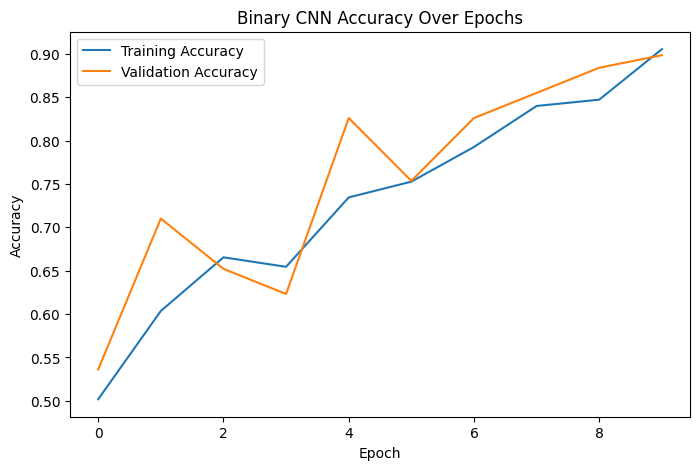

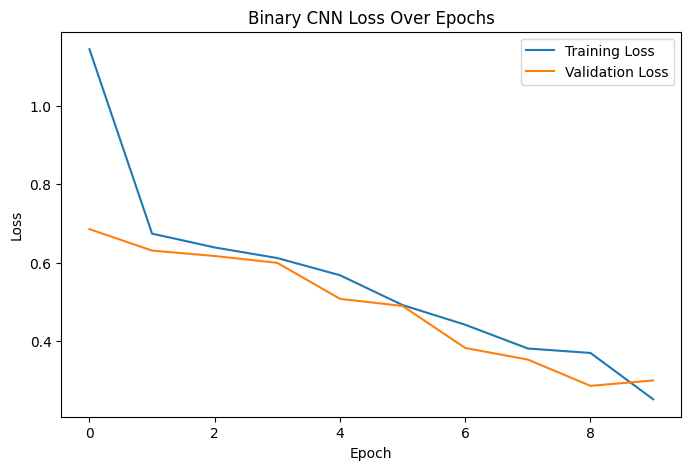

In [48]:
# Plot binary model accuracy
plt.figure(figsize=(8, 5))

plt.plot(binary_history.history['accuracy'], label='Training Accuracy')
plt.plot(binary_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Binary CNN Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()


# Plot binary model loss
plt.figure(figsize=(8, 5))

plt.plot(binary_history.history['loss'], label='Training Loss')
plt.plot(binary_history.history['val_loss'], label='Validation Loss')

plt.title('Binary CNN Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

The binary CNN accuracy plot showed that both training and validation accuracy improved steadily over the epochs. Training accuracy increased to over 90%, while validation accuracy peaked around 88%, showing that the model was learning useful patterns from the bird spectrograms. The loss plot also showed both training and validation loss decreasing over time, which indicates the model was improving during training. Near the final epochs, validation loss increased slightly while training loss continued decreasing, suggesting mild overfitting toward the end of training.


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


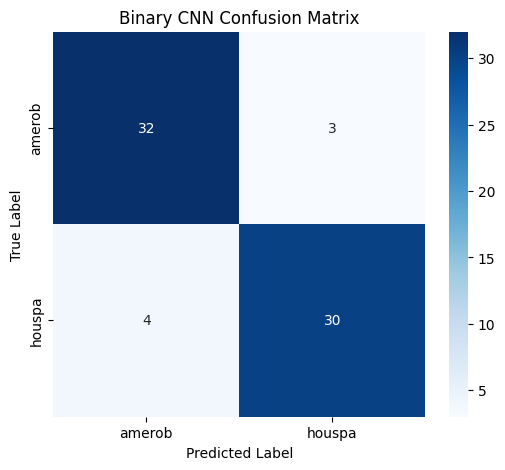

              precision    recall  f1-score   support

      amerob       0.89      0.91      0.90        35
      houspa       0.91      0.88      0.90        34

    accuracy                           0.90        69
   macro avg       0.90      0.90      0.90        69
weighted avg       0.90      0.90      0.90        69



In [49]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict binary test labels
binary_predictions = binary_model.predict(Xb_test)

# Convert probabilities to 0 or 1
binary_predicted_labels = (binary_predictions > 0.5).astype(int)

# Confusion matrix
binary_cm = confusion_matrix(yb_test, binary_predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    binary_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[species_a, species_b],
    yticklabels=[species_a, species_b]
)

plt.title('Binary CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

# Classification report
binary_report = classification_report(
    yb_test,
    binary_predicted_labels,
    target_names=[species_a, species_b]
)

print(binary_report)

Section 16 Summary: The binary CNN model performed much better than the multi-class model. Using only the amerob and houspa bird species, the network achieved approximately 89.9% test accuracy with a test loss of 0.30. The confusion matrix showed that the model correctly classified most samples from both classes, with only a small number of misclassifications. Overall, the binary classification task was much easier because the model only needed to distinguish between two bird species instead of all 12 species.

## Section 16B: Binary CNN Hyperparameter Tuning

In this section, we explored whether modifying the binary CNN architecture and training settings could improve performance. The original binary model achieved approximately 89.9% test accuracy. To investigate the effect of hyperparameter tuning, we tested an alternative architecture with additional convolutional layers and different regularization settings. The goal was to determine whether increased model complexity would improve classification performance or lead to overfitting.

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

tuned_binary_model = Sequential()

tuned_binary_model.add(Conv2D(16, (3,3), activation='relu', input_shape=(128,517,1)))
tuned_binary_model.add(MaxPooling2D((2,2)))

tuned_binary_model.add(Conv2D(32, (3,3), activation='relu'))
tuned_binary_model.add(MaxPooling2D((2,2)))

# Additional convolution layer
tuned_binary_model.add(Conv2D(64, (3,3), activation='relu'))
tuned_binary_model.add(MaxPooling2D((2,2)))

tuned_binary_model.add(Flatten())

tuned_binary_model.add(Dense(128, activation='relu'))
tuned_binary_model.add(Dropout(0.5))

tuned_binary_model.add(Dense(1, activation='sigmoid'))

tuned_binary_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

tuned_binary_model.summary()

/opt/anaconda3/envs/ml311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 126, 515, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 63, 257, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 61, 255, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 55552)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     7,110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,134,209 (27.21 MB)

 Trainable params: 7,134,209 (27.21 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
tuned_history = tuned_binary_model.fit(
    Xb_train,
    yb_train,
    epochs=10,
    batch_size=16,
    validation_data=(Xb_test, yb_test)
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.4800 - loss: 0.7589 - val_accuracy: 0.5942 - val_loss: 0.6752
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.6182 - loss: 0.6544 - val_accuracy: 0.5362 - val_loss: 0.7792
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.6836 - loss: 0.6136 - val_accuracy: 0.7826 - val_loss: 0.5110
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.7418 - loss: 0.5077 - val_accuracy: 0.8261 - val_loss: 0.4219
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.8436 - loss: 0.3883 - val_accuracy: 0.8696 - val_loss: 0.3440
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.8218 - loss: 0.3644 - val_accuracy: 0.8406 - val_loss: 0.3343
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.8764 - loss: 0.3301 - val_accuracy: 0.8261 - val_loss: 0.3406
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.8655 - loss: 0.2848 - val_accuracy: 0.

In [52]:
tuned_loss, tuned_accuracy = tuned_binary_model.evaluate(
    Xb_test,
    yb_test
)

print("Tuned Binary Test Loss:", tuned_loss)
print("Tuned Binary Test Accuracy:", tuned_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8841 - loss: 0.4148
Tuned Binary Test Loss: 0.4147680103778839
Tuned Binary Test Accuracy: 0.8840579986572266


Section 16B Summary: Hyperparameter tuning produced a strong binary classification model, achieving approximately 88.4% test accuracy and a test loss of 0.41. Validation accuracy remained consistently high throughout training, indicating good generalization. Although the tuned model performed well, it did not surpass the original Binary CNN, which achieved approximately 89.9% test accuracy. These results suggest that increasing model complexity did not provide additional performance benefits for this binary classification task.

In [53]:
# Binary model comparison

binary_comparison_df = pd.DataFrame({
    "Model": [
        "Binary CNN",
        "Tuned Binary CNN"
    ],
    "Test Accuracy": [
        round(binary_test_accuracy, 4),
        round(tuned_accuracy, 4)
    ],
    "Test Loss": [
        round(binary_test_loss, 4),
        round(tuned_loss, 4)
    ]
})

display(binary_comparison_df)

,Model,Test Accuracy,Test Loss
0,Binary CNN,0.8986,0.2998
1,Tuned Binary CNN,0.8841,0.4148


Binary Model Comparison: The original Binary CNN achieved the highest test accuracy at approximately 89.9%, while the Tuned Binary CNN achieved 88.4%. Although hyperparameter tuning produced competitive performance, it did not improve upon the original model. Both models performed substantially better than the multi-class CNN, demonstrating that distinguishing between two bird species is a much easier classification task.

## Section 17: Analyze External Test Clips More Deeply

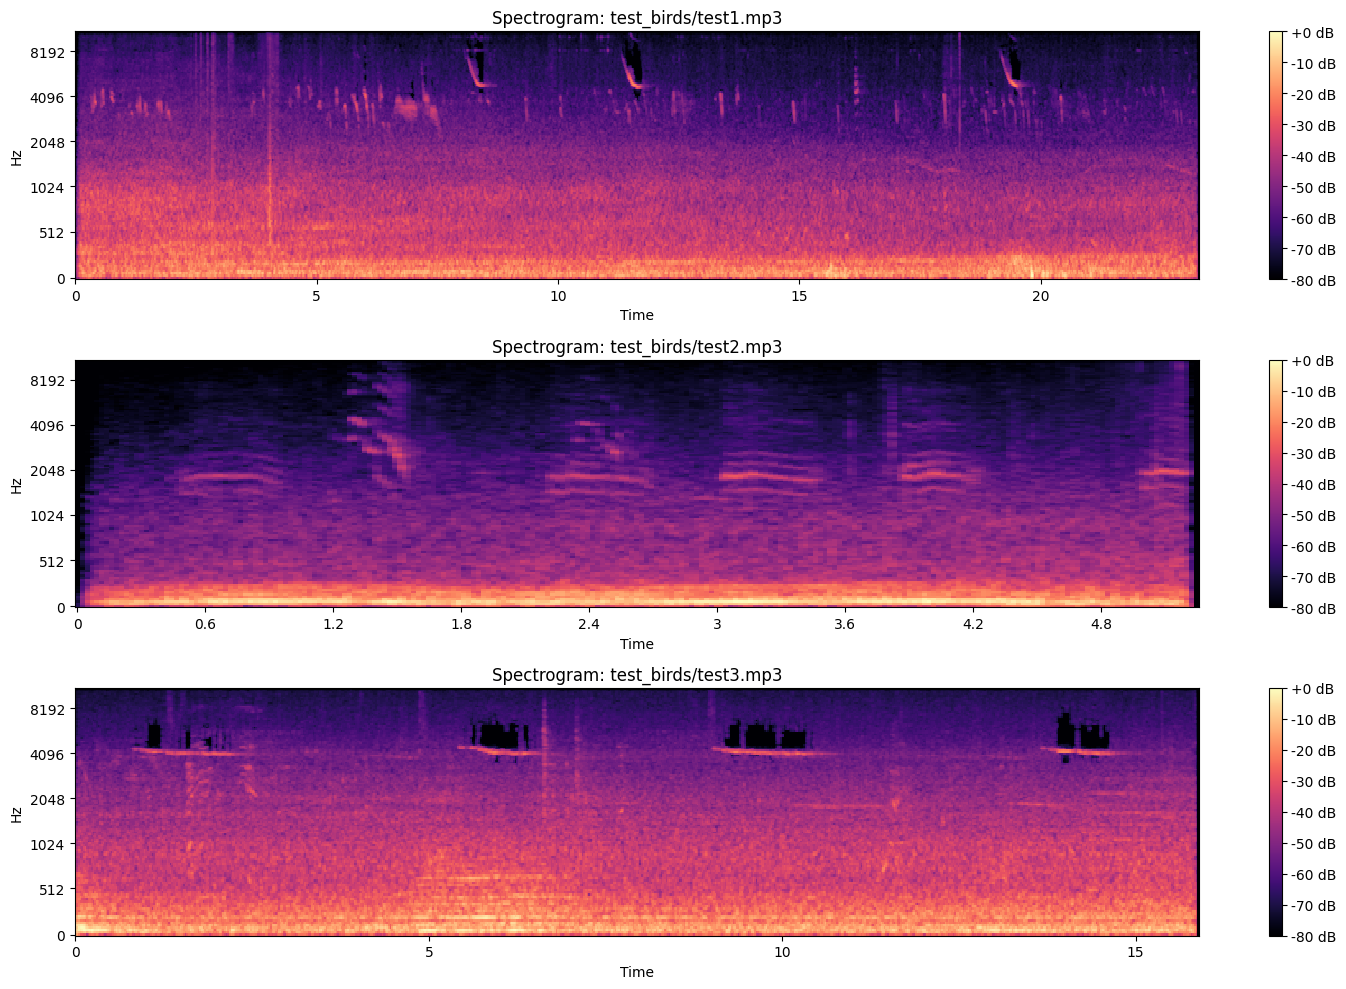

In [61]:
# Display spectrograms for external test clips

test_files = [
    "test_birds/test1.mp3",
    "test_birds/test2.mp3",
    "test_birds/test3.mp3"
]

plt.figure(figsize=(15, 10))

for i, file_path in enumerate(test_files):

    y_audio, sr = librosa.load(file_path, sr=22050)

    mel_spec = librosa.feature.melspectrogram(
        y=y_audio,
        sr=sr,
        n_mels=128
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.subplot(3, 1, i + 1)

    librosa.display.specshow(
        mel_spec_db,
        sr=sr,
        x_axis='time',
        y_axis='mel'
    )

    plt.colorbar(format='%+2.0f dB')

    plt.title(f"Spectrogram: {file_path}")

plt.tight_layout()
plt.show()

## External Test Clip Analysis

The spectrograms for the three external test clips showed different sound patterns and frequency distributions over time. Based on the final CNN predictions, all three audio clips were classified as houspa. The confidence scores ranged from about 28% to 64%, which shows that the model was still uncertain for some clips.

Test2.mp3 had the highest confidence score and appeared to have the clearest repeating bird call structure. Test1.mp3 and test3.mp3 looked more complex, with more scattered high-frequency sounds and background noise. This may explain why the model had lower confidence for those clips.

Overall, the spectrogram analysis helped show why some clips were easier for the CNN to classify than others. Cleaner and more repetitive sound patterns produced stronger predictions, while noisier clips were more difficult for the model.


In [67]:
final_predictions = pd.DataFrame({
    "Audio Clip": [p["file"].split("/")[-1] for p in test_predictions],
    "Predicted Species": [p["predicted_species"] for p in test_predictions],
    "Confidence": [round(p["confidence"], 4) for p in test_predictions]
})

display(final_predictions)

,Audio Clip,Predicted Species,Confidence
0,test1.mp3,houspa,0.3752
1,test2.mp3,houspa,0.6421
2,test3.mp3,houspa,0.2834


## GitHub: Access to report

https://github.com/hamdahass/DATA5322-Practical-Homework